# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [7]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")



In [8]:
pip install pandas pyarrow fastparquet geopandas


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.3.2
matplotlib version: 3.9.4
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [13]:
df.shape

NameError: name 'df' is not defined

In [31]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()
df1 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-1.parquet')

In [ ]:
df1.shape

In [16]:
df2 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-2.parquet')

In [17]:
df2.shape

(3374086, 19)

In [18]:
df3 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-3.parquet')
df4 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-4.parquet')
df5 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-5.parquet')
df6 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-6.parquet')
df7 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-7.parquet')
df8 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-8.parquet')
df9 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-9.parquet')
df10 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-10.parquet')
df11 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-11.parquet')
df12 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-12.parquet')








In [19]:
df3.shape

(3275796, 19)

In [20]:
df4.shape

(2792901, 19)

In [21]:
df5.shape

(2889185, 19)

In [22]:
df6.shape

(3258261, 19)

In [23]:
df7.shape

(3481547, 19)

In [24]:
df8.shape

(2875947, 19)

In [25]:
df9.shape

(2817156, 19)

In [26]:
df10.shape

(3485185, 19)

In [27]:
df11.shape

(3302857, 19)

In [28]:
df12.shape

(3333925, 19)

In [32]:
df1.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00
5,2,2023-01-01 00:50:34,2023-01-01 01:02:52,1.0,1.84,1.0,N,161,137,1,12.8,1.00,0.5,10.00,0.0,1.0,27.80,2.5,0.00
6,2,2023-01-01 00:09:22,2023-01-01 00:19:49,1.0,1.66,1.0,N,239,143,1,12.1,1.00,0.5,3.42,0.0,1.0,20.52,2.5,0.00
7,2,2023-01-01 00:27:12,2023-01-01 00:49:56,1.0,11.70,1.0,N,142,200,1,45.7,1.00,0.5,10.74,3.0,1.0,64.44,2.5,0.00
8,2,2023-01-01 00:21:44,2023-01-01 00:36:40,1.0,2.95,1.0,N,164,236,1,17.7,1.00,0.5,5.68,0.0,1.0,28.38,2.5,0.00
9,2,2023-01-01 00:39:42,2023-01-01 00:50:36,1.0,3.01,1.0,N,141,107,2,14.9,1.00,0.5,0.00,0.0,1.0,19.90,2.5,0.00


In [33]:
df2.head(30)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2023-03-01 00:06:43,2023-03-01 00:16:43,1.0,0.00,1.0,N,238,42,2,8.6,1.00,0.5,0.00,0.00,1.0,11.10,0.0,0.00
1,2,2023-03-01 00:08:25,2023-03-01 00:39:30,2.0,12.40,1.0,N,138,231,1,52.7,6.00,0.5,12.54,0.00,1.0,76.49,2.5,1.25
2,1,2023-03-01 00:15:04,2023-03-01 00:29:26,0.0,3.30,1.0,N,140,186,1,18.4,3.50,0.5,4.65,0.00,1.0,28.05,2.5,0.00
3,1,2023-03-01 00:49:37,2023-03-01 01:01:05,1.0,2.90,1.0,N,140,43,1,15.6,3.50,0.5,4.10,0.00,1.0,24.70,2.5,0.00
4,2,2023-03-01 00:08:04,2023-03-01 00:11:06,1.0,1.23,1.0,N,79,137,1,7.2,1.00,0.5,2.44,0.00,1.0,14.64,2.5,0.00
5,1,2023-03-01 00:09:09,2023-03-01 00:17:34,1.0,1.20,1.0,N,162,137,1,10.0,3.50,0.5,3.00,0.00,1.0,18.00,2.5,0.00
6,1,2023-03-01 00:32:21,2023-03-01 00:42:08,1.0,1.80,1.0,N,170,48,1,12.1,3.50,0.5,3.40,0.00,1.0,20.50,2.5,0.00
7,1,2023-03-01 00:45:12,2023-03-01 00:52:37,1.0,2.00,1.0,N,48,164,2,10.7,3.50,0.5,0.00,0.00,1.0,15.70,2.5,0.00
8,1,2023-03-01 00:19:43,2023-03-01 00:39:37,1.0,5.30,1.0,N,113,61,1,26.1,3.50,0.5,9.30,0.00,1.0,40.40,2.5,0.00
9,2,2023-03-01 00:08:42,2023-03-01 00:18:45,1.0,2.27,1.0,N,239,263,1,13.5,1.00,0.5,3.70,0.00,1.0,22.20,2.5,0.00


In [34]:
df2.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='object')

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'


sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

In [35]:
df1['tpep_pickup_datetime'].dtype

dtype('<M8[us]')

dtype('<M8[us]') indicates the column is a NumPy datetime64 type with microsecond precision, enabling direct datetime-based operations like hour-wise or date-wise grouping.Since its already in datetime format.

In [36]:
df1['pickup_date'] = df1['tpep_pickup_datetime'].dt.date

In [37]:
df1['pickup_date']

0          2023-01-01
1          2023-01-01
2          2023-01-01
3          2023-01-01
4          2023-01-01
              ...    
3066761    2023-01-31
3066762    2023-01-31
3066763    2023-01-31
3066764    2023-01-31
3066765    2023-01-31
Name: pickup_date, Length: 3041714, dtype: object

In [38]:
df1['pickup_hour'] = df1['tpep_pickup_datetime'].dt.hour

In [39]:
df1['pickup_hour']

0           0
1           0
2           0
3           0
4           0
           ..
3066761    23
3066762    23
3066763    23
3066764    23
3066765    23
Name: pickup_hour, Length: 3041714, dtype: int32

In [40]:
sample_df1 = df1.groupby(['pickup_date' , 'pickup_hour'] , group_keys=False).apply(lambda x : x.sample(frac= 0.05 , random_state= 42)).reset_index(drop=True)


In [41]:
sample_df1

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,N,141,140,1,...,1.0,0.5,2.00,0.0,1.0,13.50,2.5,0.00,2022-12-31,23
1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0
2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0
3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0
4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152082,2,2023-01-31 23:40:44,2023-01-31 23:46:43,2.0,1.98,1.0,N,161,236,2,...,1.0,0.5,0.00,0.0,1.0,15.00,2.5,0.00,2023-01-31,23
152083,2,2023-01-31 23:28:47,2023-01-31 23:36:57,5.0,1.63,1.0,N,137,113,2,...,1.0,0.5,0.00,0.0,1.0,15.70,2.5,0.00,2023-01-31,23
152084,2,2023-01-31 23:35:26,2023-01-31 23:40:39,1.0,0.87,1.0,N,79,148,1,...,1.0,0.5,2.44,0.0,1.0,14.64,2.5,0.00,2023-01-31,23
152085,2,2023-01-31 23:12:04,2023-01-31 23:23:56,1.0,2.53,1.0,N,90,148,1,...,1.0,0.5,3.84,0.0,1.0,23.04,2.5,0.00,2023-01-31,23


**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [42]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [43]:
# from google.colab import drive
# drive.mount('/content/drive')

# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file



        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date

            # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe

        # Concatenate the sampled data of all the dates to a single dataframe
        df = # we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [44]:
import os
import gc

In [45]:
os.chdir('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records')

In [46]:
file_list= os.listdir()

In [47]:
file_list

['2023-12.parquet',
 '2023-6.parquet',
 '2023-7.parquet',
 '.DS_Store',
 '2023-5.parquet',
 '2023-11.parquet',
 '2023-10.parquet',
 'nyc_taxi_sampled.csv',
 '2023-4.parquet',
 '2023-1.parquet',
 '2023-8.parquet',
 '2023-9.parquet',
 '2023-2.parquet',
 '2023-3.parquet']

In [48]:
df = pd.DataFrame()

In [49]:
for file_name in file_list:
    try:
        file_path = os.path.join(os.getcwd(), file_name)
        
        month_df = pd.read_parquet(file_path)
        month_df['pickup_date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['pickup_hour'] = month_df['tpep_pickup_datetime'].dt.hour
        sampled_data = pd.DataFrame()
        for date in month_df['pickup_date'].unique():
            date_df = month_df[month_df['pickup_date'] == date]
            for hour in range(24):
                hour_df = date_df[date_df['pickup_hour']== hour]
                if len(hour_df)>0:
                    sample = hour_df.sample(frac=0.05, random_state=42)
                    sampled_data = pd.concat([sampled_data , sample])
        df= pd.concat([df , sampled_data] , ignore_index=True)
        del month_df, sampled_data
        gc.collect()
        print(f"Processed file: {file_name}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
    
        


Processed file: 2023-12.parquet
Processed file: 2023-6.parquet
Processed file: 2023-7.parquet
Error reading file .DS_Store: Could not open Parquet input source '<Buffer>': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.
Processed file: 2023-5.parquet
Processed file: 2023-11.parquet
Processed file: 2023-10.parquet
Error reading file nyc_taxi_sampled.csv: Could not open Parquet input source '<Buffer>': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.
Processed file: 2023-4.parquet
Processed file: 2023-1.parquet
Processed file: 2023-8.parquet
Processed file: 2023-9.parquet
Processed file: 2023-2.parquet
Processed file: 2023-3.parquet


In [50]:
del df1

In [71]:
df1.head()

NameError: name 'df1' is not defined

In [72]:
df1 = pd.read_parquet('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/2023-1.parquet')

In [73]:
df1.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [74]:
df1.shape

(3041714, 19)

In [75]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [ ]:
# Store the df in csv/parquet
# df.to_parquet('')

In [76]:
df.shape

(1896400, 22)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [78]:
df.to_csv('nyc_taxi_sampled.csv', index=False)

In [79]:
import os
os.getcwd()

'/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records'

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [80]:
# Load the new data file

df = pd.read_csv('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/trip_records/nyc_taxi_sampled.csv')

In [81]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_hour,airport_fee
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,0.5,5.66,0.0,1.0,33.96,2.5,0.0,2023-12-01,0,NaN
1,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,0.5,3.00,0.0,1.0,29.43,0.0,NaN,2023-12-01,0,NaN
2,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,0.5,3.14,0.0,1.0,18.84,2.5,0.0,2023-12-01,0,NaN
3,2,2023-12-01 00:00:50,2023-12-01 00:14:37,1.0,2.08,1.0,Unknown,137,144,0,...,0.5,0.00,0.0,1.0,21.22,0.0,NaN,2023-12-01,0,NaN
4,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,...,0.5,0.00,0.0,1.0,10.10,2.5,0.0,2023-12-01,0,NaN


In [82]:
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  Airport_fee            float64
 19  pickup_date            object 
 20  pickup_hour            int64  
 21  airport_fee            float64
dtypes: float64(13), in

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [83]:
# Fix the index and drop any columns that are not needed

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['pickup_date'] = pd.to_datetime(df['pickup_date'])

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [85]:
df['store_and_fwd_flag'].dtype

dtype('O')

In [86]:
df['store_and_fwd_flag'].head(25)

0           N
1     Unknown
2           N
3     Unknown
4           N
5           N
6           N
7           N
8           N
9           N
10          N
11          N
12          N
13          N
14          N
15          N
16          N
17          N
18          N
19          N
20          N
21          N
22          N
23          N
24          N
Name: store_and_fwd_flag, dtype: object

In [87]:
df['Airport_fee'].head(10)

0    0.0
1    NaN
2    0.0
3    NaN
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: Airport_fee, dtype: float64

In [88]:
df['airport_fee'].head(10)

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: airport_fee, dtype: float64

In [89]:
df.reset_index(drop = True , inplace= True)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [91]:
# Combine the two airport fee columns
df['airport_fee'].value_counts().sum()

np.int64(148483)

In [92]:
df['Airport_fee'].value_counts().sum()

np.int64(1683043)

In [93]:
df['airport_fee'].value_counts().sum()+df['Airport_fee'].value_counts().sum()

np.int64(1831526)

In [94]:
df['airport_fee_final'] = df['Airport_fee'].fillna(df['airport_fee'])

In [95]:
df['airport_fee_final'].head()

0    0.0
1    NaN
2    0.0
3    NaN
4    0.0
Name: airport_fee_final, dtype: float64

In [96]:
df['airport_fee_final'].value_counts().sum()

np.int64(1831526)

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [97]:
# check where values of fare amount are negative

(df['fare_amount']<0).sum()

np.int64(0)

In [98]:
df['fare_amount'].head(40)

0     23.30
1     22.43
2     10.70
3     17.22
4      5.10
5     10.70
6     14.90
7     11.00
8      8.60
9      7.90
10    11.00
11    16.30
12    14.90
13    11.40
14    45.70
15    21.90
16     5.80
17    12.80
18    12.10
19     7.90
20    10.70
21    10.00
22     3.70
23     9.30
24     6.50
25     6.50
26     7.90
27    17.83
28    19.80
29    19.80
30     9.30
31     5.80
32     7.90
33    19.80
34    76.50
35    13.50
36    13.50
37     7.90
38    33.10
39     9.30
Name: fare_amount, dtype: float64

Did you notice something different in the `RatecodeID` column for above records?

In [99]:
# Analyse RatecodeID for the negative fare amounts

neg_fare_df = df[df['fare_amount'] < 0]

In [100]:
neg_fare_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_hour,airport_fee,airport_fee_final


In [101]:
neg_fare_df['RatecodeID'].value_counts()

Series([], Name: count, dtype: int64)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [103]:
# Find which columns have negative values

numeric_columns = df.select_dtypes(include = ['int64' , 'float64']).columns

In [104]:
numeric_columns 

Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee', 'pickup_hour',
       'airport_fee', 'airport_fee_final'],
      dtype='object')

In [105]:
neg_counts = (df[numeric_columns] <0).sum()
neg_counts

VendorID                  0
passenger_count           0
trip_distance             0
RatecodeID                0
PULocationID              0
DOLocationID              0
payment_type              0
fare_amount               0
extra                     3
mta_tax                  73
tip_amount                0
tolls_amount              0
improvement_surcharge    78
total_amount             78
congestion_surcharge     56
Airport_fee              14
pickup_hour               0
airport_fee               1
airport_fee_final        15
dtype: int64

In [106]:
# fix these negative values
df.loc[df['extra'] < 0, 'extra'] = 0



In [107]:
df.loc[df['mta_tax']<0 , 'mta_tax'] =0

In [108]:
df.loc[df['improvement_surcharge'] < 0, 'improvement_surcharge'] = 0


In [109]:
df.loc[df['congestion_surcharge'] < 0, 'congestion_surcharge'] = 0


In [110]:
df.loc[df['airport_fee_final'] < 0, 'airport_fee_final'] = 0


In [111]:
neg_counts1 = (df[numeric_columns]<0).sum()
neg_counts1

VendorID                  0
passenger_count           0
trip_distance             0
RatecodeID                0
PULocationID              0
DOLocationID              0
payment_type              0
fare_amount               0
extra                     0
mta_tax                   0
tip_amount                0
tolls_amount              0
improvement_surcharge     0
total_amount             78
congestion_surcharge      0
Airport_fee              14
pickup_hour               0
airport_fee               1
airport_fee_final         0
dtype: int64

In [112]:
df.drop(columns= ['Airport_fee' , 'airport_fee'] , inplace=True)

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  pickup_date           

In [114]:
numeric_columns = numeric_columns.drop(['Airport_fee' , 'airport_fee'])

In [115]:
neg_counts1 = (df[numeric_columns]<0).sum()
neg_counts1

VendorID                  0
passenger_count           0
trip_distance             0
RatecodeID                0
PULocationID              0
DOLocationID              0
payment_type              0
fare_amount               0
extra                     0
mta_tax                   0
tip_amount                0
tolls_amount              0
improvement_surcharge     0
total_amount             78
congestion_surcharge      0
pickup_hour               0
airport_fee_final         0
dtype: int64

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [116]:
# Find the proportion of missing values in each column

df.isna().sum().sort_values(ascending=False)

airport_fee_final        64874
extra                        0
pickup_hour                  0
pickup_date                  0
congestion_surcharge         0
total_amount                 0
improvement_surcharge        0
tolls_amount                 0
tip_amount                   0
mta_tax                      0
VendorID                     0
tpep_pickup_datetime         0
payment_type                 0
DOLocationID                 0
PULocationID                 0
store_and_fwd_flag           0
RatecodeID                   0
trip_distance                0
passenger_count              0
tpep_dropoff_datetime        0
fare_amount                  0
dtype: int64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [117]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
df[df['passenger_count'].isna()].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_date,pickup_hour,airport_fee_final


Did you find zeroes in passenger_count? Handle these.

In [118]:
df['passenger_count'].value_counts(dropna=False)

passenger_count
1.0    1442098
2.0     277298
3.0      69034
4.0      38537
0.0      29681
5.0      23871
6.0      15860
8.0         11
9.0          5
7.0          5
Name: count, dtype: int64

<Axes: ylabel='passenger_count'>

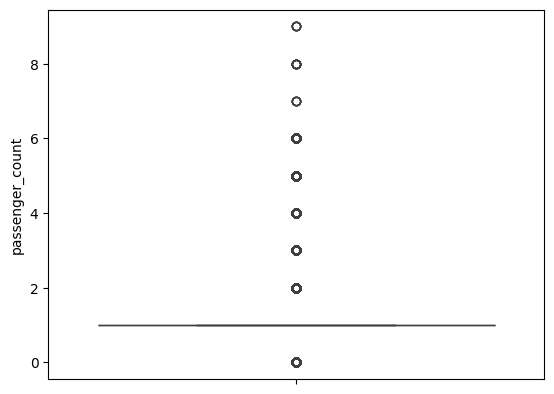

In [119]:
import seaborn as sns
sns.boxplot(df['passenger_count'])

In [120]:
df['passenger_count'].fillna(df['passenger_count'].median() , inplace=True)

In [121]:
df.isna().sum().sort_values(ascending=False)

airport_fee_final        64874
extra                        0
pickup_hour                  0
pickup_date                  0
congestion_surcharge         0
total_amount                 0
improvement_surcharge        0
tolls_amount                 0
tip_amount                   0
mta_tax                      0
VendorID                     0
tpep_pickup_datetime         0
payment_type                 0
DOLocationID                 0
PULocationID                 0
store_and_fwd_flag           0
RatecodeID                   0
trip_distance                0
passenger_count              0
tpep_dropoff_datetime        0
fare_amount                  0
dtype: int64

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

This is a categorical code, not a continuous numeric variable

In [122]:
# Fix missing values in 'RatecodeID'
df['RatecodeID'].value_counts()

RatecodeID
1.0     1794133
2.0       71670
99.0      10472
5.0       10275
3.0        6124
4.0        3723
6.0           3
Name: count, dtype: int64

In [123]:
df['RatecodeID'].fillna(df['RatecodeID'].mode()[0] , inplace=True)

In [124]:
df.isna().sum().sort_values(ascending=False)

airport_fee_final        64874
extra                        0
pickup_hour                  0
pickup_date                  0
congestion_surcharge         0
total_amount                 0
improvement_surcharge        0
tolls_amount                 0
tip_amount                   0
mta_tax                      0
VendorID                     0
tpep_pickup_datetime         0
payment_type                 0
DOLocationID                 0
PULocationID                 0
store_and_fwd_flag           0
RatecodeID                   0
trip_distance                0
passenger_count              0
tpep_dropoff_datetime        0
fare_amount                  0
dtype: int64

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [125]:
# handle null values in congestion_surcharge

df['congestion_surcharge'].value_counts(dropna=False)


congestion_surcharge
2.5    1690572
0.0     205827
0.5          1
Name: count, dtype: int64

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [126]:
# Handle any remaining missing values
df['congestion_surcharge'].fillna(0 , inplace= True)

In [127]:
df['airport_fee_final'].fillna(0 , inplace= True)

In [128]:
df.isna().sum().sort_values(ascending=False)

VendorID                 0
extra                    0
pickup_hour              0
pickup_date              0
congestion_surcharge     0
total_amount             0
improvement_surcharge    0
tolls_amount             0
tip_amount               0
mta_tax                  0
fare_amount              0
tpep_pickup_datetime     0
payment_type             0
DOLocationID             0
PULocationID             0
store_and_fwd_flag       0
RatecodeID               0
trip_distance            0
passenger_count          0
tpep_dropoff_datetime    0
airport_fee_final        0
dtype: int64

In [129]:
df['store_and_fwd_flag'].head()

0          N
1    Unknown
2          N
3    Unknown
4          N
Name: store_and_fwd_flag, dtype: object

In [130]:
df['store_and_fwd_flag'].fillna('Unknown', inplace=True)


In [131]:
df.isna().sum().sort_values(ascending=False)

VendorID                 0
extra                    0
pickup_hour              0
pickup_date              0
congestion_surcharge     0
total_amount             0
improvement_surcharge    0
tolls_amount             0
tip_amount               0
mta_tax                  0
fare_amount              0
tpep_pickup_datetime     0
payment_type             0
DOLocationID             0
PULocationID             0
store_and_fwd_flag       0
RatecodeID               0
trip_distance            0
passenger_count          0
tpep_dropoff_datetime    0
airport_fee_final        0
dtype: int64

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [132]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df[numeric_columns].describe()


,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_hour,airport_fee_final
count,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06
mean,1.733026e+00,1.356585e+00,3.858293e+00,1.612981e+00,1.652814e+02,1.640515e+02,1.163817e+00,1.991935e+01,1.588020e+00,4.952989e-01,3.547011e+00,5.965338e-01,9.990118e-01,2.898186e+01,2.228660e+00,1.426504e+01,1.380220e-01
std,4.476401e-01,8.799160e-01,1.294085e+02,7.267261e+00,6.400038e+01,6.980207e+01,5.081384e-01,1.055371e+02,1.829197e+00,4.855675e-02,4.054882e+00,2.187878e+00,2.907216e-02,1.064162e+02,7.776405e-01,5.807381e+00,4.575627e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.750000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,1.100000e+01,0.000000e+00
50%,2.000000e+00,1.000000e+00,1.790000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,1.500000e+01,0.000000e+00
75%,2.000000e+00,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,1.900000e+01,0.000000e+00
max,6.000000e+00,9.000000e+00,1.263605e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,2.300000e+01,1.750000e+00


<b><h1>Analysis of outliers</b></h1>

Trip distance has min-0 , 25% = 1.05
50% = 1.79
75% = 3.40
max = 126,360 miles


If max is wayyyyy bigger than 75%, it’s an outlier.

Fare_amount --% = 9.3
50% = 13.5
75% = 21.9
max = 143,163
If max is wayyyyy bigger than 75%, it’s an outlier.

passenger count min is zero that means its an error , for a trip passenger count cant be zero , 

RatecodeID max 99  incorrect entry

 extra --min = 0
25% = 0
50% = 1
75% = 2.5
max = 20.8 20.8 is still as metadata

mta_tax MTA tax is fixed at 0.5
👉 Values > 0.5 are incorrect entries

total_amount
Normal tips are 1–4

Some tips are 223

🚨 Extremely high tip
👉 Possible outlier (or rare case)

Most trips have no tolls

Some trips have 143

🚨 Very high toll amount
👉 Possible data error or extreme outlier

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [134]:
# remove passenger_count > 6
df_clean = df[df['passenger_count']<= 6]

In [135]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896379 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  pickup_date            date

In [136]:
# Continue with outlier handling
df_clean[(df_clean['trip_distance']<0.1) & (df_clean['fare_amount'] > 300)].shape


(35, 21)

In [137]:
df_clean = df_clean[~((df_clean['trip_distance']<0.1) & (df_clean['fare_amount'] > 300))]

In [138]:
df_clean.shape

(1896344, 21)

In [139]:
df_clean = df_clean[~(
    (df_clean['trip_distance']==0) & 
    (df_clean['fare_amount']==0) &
    (df_clean['PULocationID'] != df_clean['DOLocationID'])
)]

In [140]:
df_clean = df_clean[~(df_clean['trip_distance'] > 250)]

In [141]:
df_clean[(df_clean['payment_type']==0)].shape

(64844, 21)

# Do any columns need standardising?

No, standardisation is not required at this stage because we are performing exploratory analysis and rule-based data cleaning, not distance-based modelling.

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [142]:
df_clean.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'pickup_date',
 'pickup_hour',
 'airport_fee_final']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  pickup_date           

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

In [144]:
# Categorical variables
categorical_cols = [
    'VendorID',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type'
]

# Numerical variables
numerical_cols = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

# Temporal variables
temporal_cols = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'pickup_hour',
    'trip_duration'
]


In [145]:
df_clean.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_date,pickup_hour,airport_fee_final
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,1.0,0.5,5.66,0.0,1.0,33.96,2.5,2023-12-01,0,0.0
1,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,0.0,0.5,3.00,0.0,1.0,29.43,0.0,2023-12-01,0,0.0
2,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,1.0,0.5,3.14,0.0,1.0,18.84,2.5,2023-12-01,0,0.0
3,2,2023-12-01 00:00:50,2023-12-01 00:14:37,1.0,2.08,1.0,Unknown,137,144,0,...,0.0,0.5,0.00,0.0,1.0,21.22,0.0,2023-12-01,0,0.0
4,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,...,1.0,0.5,0.00,0.0,1.0,10.10,2.5,2023-12-01,0,0.0
5,2,2023-12-01 00:57:08,2023-12-01 01:05:49,1.0,1.66,1.0,N,114,186,1,...,1.0,0.5,3.14,0.0,1.0,18.84,2.5,2023-12-01,0,0.0
6,2,2023-12-01 00:46:28,2023-12-01 00:59:29,2.0,2.45,1.0,N,164,232,1,...,1.0,0.5,1.00,0.0,1.0,20.90,2.5,2023-12-01,0,0.0
7,2,2023-12-01 00:36:28,2023-12-01 00:36:34,1.0,0.00,5.0,N,170,170,1,...,0.0,0.0,2.90,0.0,1.0,17.40,2.5,2023-12-01,0,0.0
8,2,2023-12-01 00:01:25,2023-12-01 00:07:45,1.0,1.08,1.0,N,114,231,1,...,1.0,0.5,2.00,0.0,1.0,15.60,2.5,2023-12-01,0,0.0
9,2,2023-12-01 00:14:06,2023-12-01 00:18:02,1.0,1.37,1.0,N,239,24,1,...,1.0,0.5,2.58,0.0,1.0,15.48,2.5,2023-12-01,0,0.0


**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [146]:
df_clean.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
pickup_date              datetime64[ns]
pickup_hour                       int64
airport_fee_final               float64
dtype: object

In [147]:
df_clean

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_date,pickup_hour,airport_fee_final
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,1.0,0.5,5.66,0.0,1.0,33.96,2.5,2023-12-01,0,0.0
1,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,0.0,0.5,3.00,0.0,1.0,29.43,0.0,2023-12-01,0,0.0
2,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,1.0,0.5,3.14,0.0,1.0,18.84,2.5,2023-12-01,0,0.0
3,2,2023-12-01 00:00:50,2023-12-01 00:14:37,1.0,2.08,1.0,Unknown,137,144,0,...,0.0,0.5,0.00,0.0,1.0,21.22,0.0,2023-12-01,0,0.0
4,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,...,1.0,0.5,0.00,0.0,1.0,10.10,2.5,2023-12-01,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896395,2,2023-06-30 23:53:10,2023-07-01 00:05:55,1.0,2.63,1.0,N,170,143,1,...,1.0,0.5,4.80,0.0,1.0,24.00,2.5,2023-06-30,23,0.0
1896396,1,2023-06-30 23:22:42,2023-06-30 23:39:06,1.0,0.00,99.0,N,90,232,1,...,0.0,0.5,0.00,0.0,1.0,19.70,0.0,2023-06-30,23,0.0
1896397,1,2023-06-30 23:50:42,2023-07-01 00:20:00,2.0,5.40,1.0,N,87,161,1,...,3.5,0.5,2.00,0.0,1.0,39.40,2.5,2023-06-30,23,0.0
1896398,1,2023-06-30 23:05:31,2023-06-30 23:15:52,1.0,1.00,1.0,N,87,231,2,...,3.5,0.5,0.00,0.0,1.0,15.70,2.5,2023-06-30,23,0.0


In [148]:
# Find and show the hourly trends in taxi pickups

df_clean['tpep_pickup_datetime'].dtype
hourly_trend = df_clean['pickup_hour'].value_counts()
hourly_trend

pickup_hour
18    133931
17    127858
19    119649
16    117497
15    117396
14    114451
13    106798
20    106580
21    106489
12    103583
22     98680
11     95425
10     87908
9      80986
23     78143
8      71809
0      53675
7      51822
1      36025
6      26322
2      23765
3      15675
5      11135
4      10633
Name: count, dtype: int64

In [149]:
hourly_trend = df_clean['pickup_hour'].value_counts().sort_index()
hourly_trend

pickup_hour
0      53675
1      36025
2      23765
3      15675
4      10633
5      11135
6      26322
7      51822
8      71809
9      80986
10     87908
11     95425
12    103583
13    106798
14    114451
15    117396
16    117497
17    127858
18    133931
19    119649
20    106580
21    106489
22     98680
23     78143
Name: count, dtype: int64

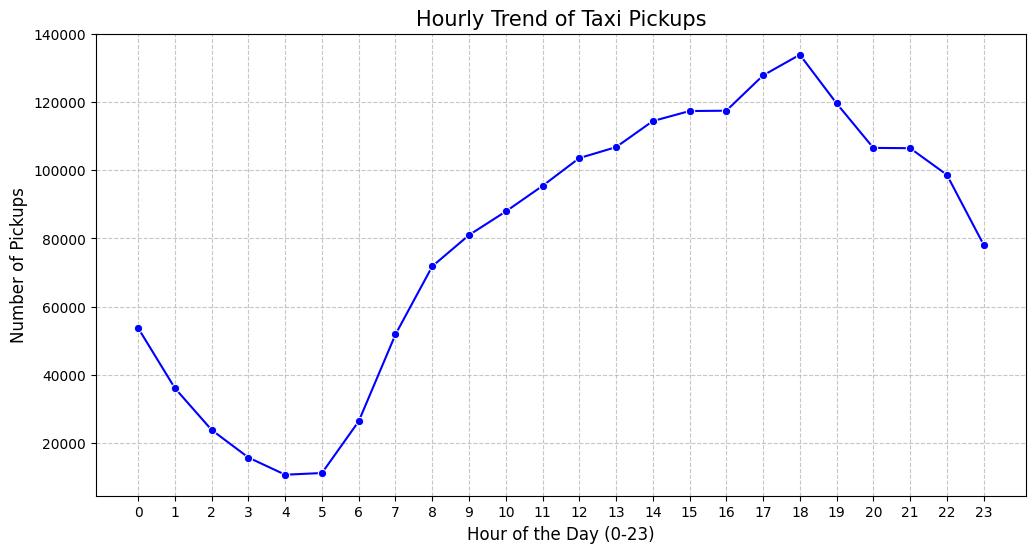

In [150]:
# Find and show the daily trends in taxi pickups (days of the week)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_trend.index, y=hourly_trend.values, marker='o', color='b')

# Adding labels and title
plt.title('Hourly Trend of Taxi Pickups', fontsize=15)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Number of Pickups', fontsize=12)
plt.xticks(range(0, 24))  # Ensure every hour is shown on the x-axis
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [151]:
# Show the monthly trends in pickups
df_clean['pickup_month'] = df_clean['pickup_date'].dt.month

In [152]:
df_clean['pickup_month']

0          12
1          12
2          12
3          12
4          12
           ..
1896395     6
1896396     6
1896397     6
1896398     6
1896399     7
Name: pickup_month, Length: 1896235, dtype: int32

In [153]:
monthly_trend = df_clean['pickup_month'].value_counts().sort_index()
monthly_trend

pickup_month
1     152073
2     144445
3     168688
4     162897
5     174053
6     163764
7     143769
8     139630
9     140866
10    174237
11    165123
12    166690
Name: count, dtype: int64

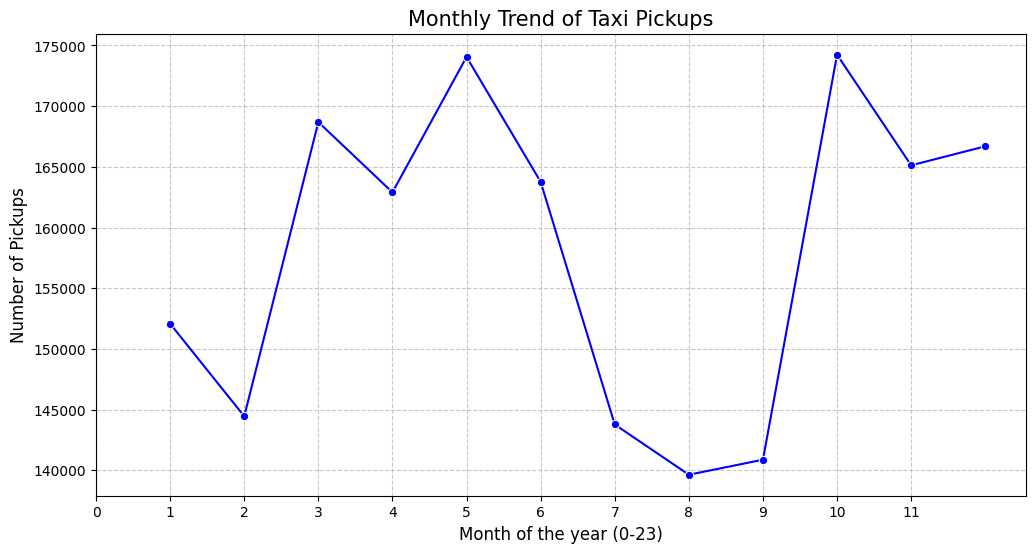

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o', color='b')

# Adding labels and title
plt.title('Monthly Trend of Taxi Pickups', fontsize=15)
plt.xlabel('Month of the year (0-23)', fontsize=12)
plt.ylabel('Number of Pickups', fontsize=12)
plt.xticks(range(0, 12))  # Ensure every hour is shown on the x-axis
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [155]:
# Analyse the above parameters

df_clean['fare_amount'].isna().sum()

np.int64(0)

In [156]:
(df_clean['fare_amount']<0).sum()

np.int64(0)

In [157]:
df_clean['tip_amount'].isna().sum()

np.int64(0)

In [158]:
(df_clean['tip_amount']<0).sum()

np.int64(0)

In [159]:
df_clean['total_amount'].isna().sum()

np.int64(0)

In [160]:
(df_clean['total_amount']<0).sum()

np.int64(74)

In [161]:
df_clean['trip_distance'].isna().sum()

np.int64(0)

In [162]:
(df_clean['trip_distance']<0).sum()

np.int64(0)

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

<b>Yes, it is highly beneficial to create a copy of your DataFrame that excludes zero values, especially for specific parts of this assignment. In data science, this is often called creating a "clean" or "subset" DataFrame for specific analyses.</b>

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

# Create a df with non zero entries for the selected parameters.

WE HAVE 'df_clean' ALREADY 

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [163]:
# Group data by month and analyse monthly revenue

grouped_df = df_clean.groupby('pickup_month')['total_amount'].sum()
grouped_df

pickup_month
1     4159838.77
2     3941698.06
3     4755378.94
4     4677001.90
5     5109339.92
6     4809056.55
7     4176586.37
8     4080229.62
9     4382977.30
10    5179104.33
11    4807563.13
12    4861626.54
Name: total_amount, dtype: float64

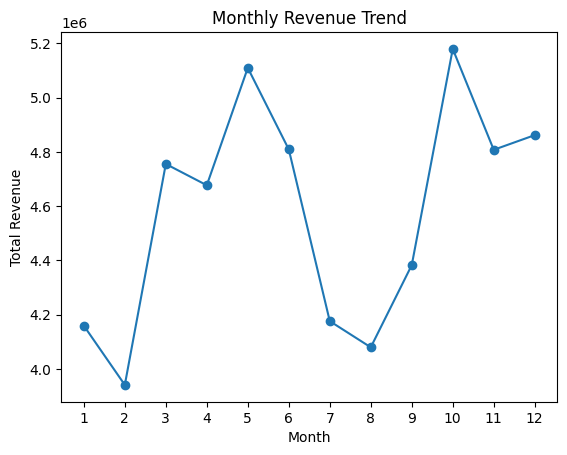

In [164]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(grouped_df.index, grouped_df.values, marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(grouped_df.index)
plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [165]:
# Calculate proportion of each quarter

import pandas as pd

# Your monthly revenue series
monthly_revenue = pd.Series({
    1: 4159838.77,
    2: 3941698.06,
    3: 4755378.94,
    4: 4677001.90,
    5: 5109339.92,
    6: 4809056.55,
    7: 4176586.37,
    8: 4080229.62,
    9: 4382977.30,
    10: 5179104.33,
    11: 4807563.13,
    12: 4861626.54
})

# Map months to quarters
quarter_revenue = monthly_revenue.groupby(
    pd.cut(monthly_revenue.index,
           bins=[0,3,6,9,12],
           labels=["Q1","Q2","Q3","Q4"])
).sum()

# Calculate proportion
quarter_proportion = quarter_revenue / quarter_revenue.sum()

quarter_proportion


Q1    0.234016
Q2    0.265659
Q3    0.230064
Q4    0.270262
dtype: float64

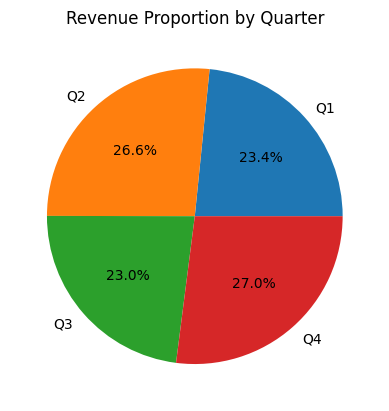

In [166]:
import matplotlib.pyplot as plt

plt.figure()
plt.pie(quarter_proportion, labels=['Q1','Q2','Q3','Q4'], autopct='%1.1f%%')
plt.title("Revenue Proportion by Quarter")
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [167]:
# Show how trip fare is affected by distance

df['trip_distance'].isna().sum()





np.int64(0)

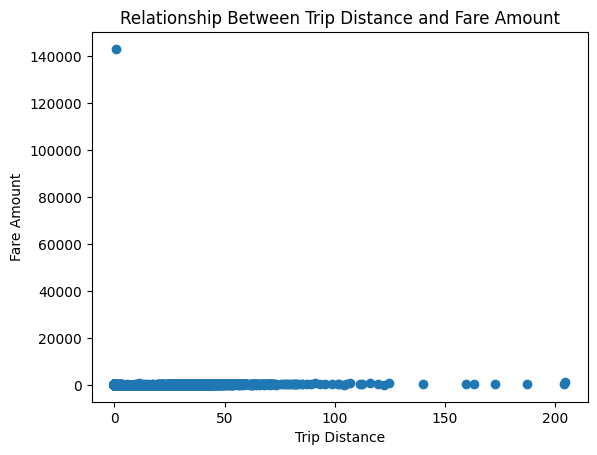

In [168]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_clean['trip_distance'],
            df_clean['fare_amount'])
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Relationship Between Trip Distance and Fare Amount")
plt.show()


In [169]:
correlation = df_clean['trip_distance'].corr(df_clean['fare_amount'])
correlation

np.float64(0.1558130379449614)

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [170]:
df_clean['trip_duration'] = df_clean['tpep_dropoff_datetime'] - df_clean['tpep_pickup_datetime']

In [171]:
df_clean['trip_duration']

0         0 days 00:22:21
1         0 days 00:23:07
2         0 days 00:10:38
3         0 days 00:13:47
4         0 days 00:03:10
                ...      
1896395   0 days 00:12:45
1896396   0 days 00:16:24
1896397   0 days 00:29:18
1896398   0 days 00:10:21
1896399   0 days 00:23:28
Name: trip_duration, Length: 1896235, dtype: timedelta64[ns]

In [172]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896235 entries, 0 to 1896399
Data columns (total 23 columns):
 #   Column                 Dtype          
---  ------                 -----          
 0   VendorID               int64          
 1   tpep_pickup_datetime   datetime64[ns] 
 2   tpep_dropoff_datetime  datetime64[ns] 
 3   passenger_count        float64        
 4   trip_distance          float64        
 5   RatecodeID             float64        
 6   store_and_fwd_flag     object         
 7   PULocationID           int64          
 8   DOLocationID           int64          
 9   payment_type           int64          
 10  fare_amount            float64        
 11  extra                  float64        
 12  mta_tax                float64        
 13  tip_amount             float64        
 14  tolls_amount           float64        
 15  improvement_surcharge  float64        
 16  total_amount           float64        
 17  congestion_surcharge   float64        
 18  pickup_

In [173]:
df_clean['trip_duration'] = df_clean['trip_duration'].dt.total_seconds() / 60


In [174]:
df_clean['trip_duration'].dtype

dtype('float64')

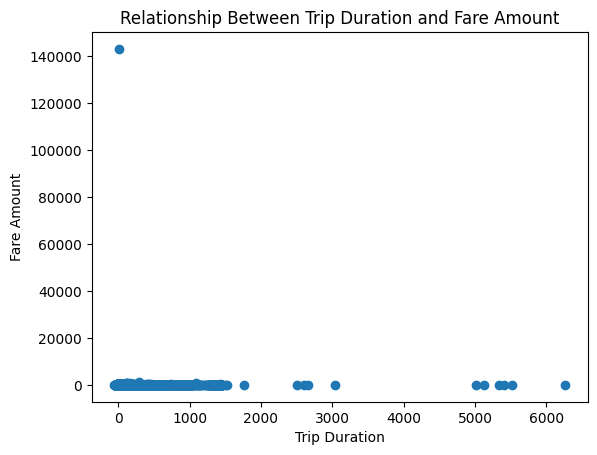

In [175]:
# Show relationship between fare and trip duration

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_clean['trip_duration'],
            df_clean['fare_amount'])
plt.xlabel("Trip Duration")
plt.ylabel("Fare Amount")
plt.title("Relationship Between Trip Duration and Fare Amount")
plt.show()


In [176]:
correlation = df_clean['trip_duration'].corr(df_clean['fare_amount'])
correlation

np.float64(0.04578723440095025)

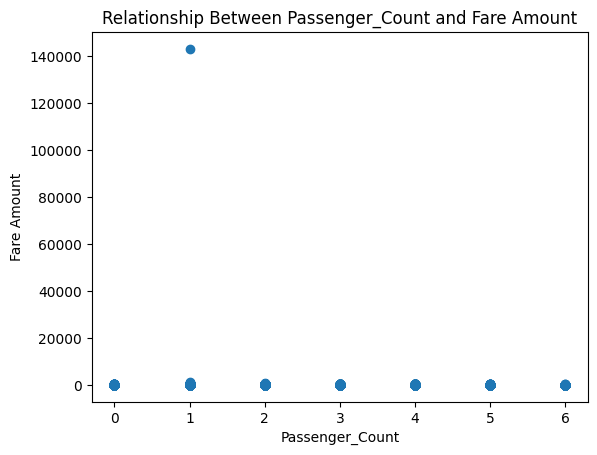

In [177]:
# Show relationship between fare and number of passengers

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_clean['passenger_count'],
            df_clean['fare_amount'])
plt.xlabel("Passenger_Count")
plt.ylabel("Fare Amount")
plt.title("Relationship Between Passenger_Count and Fare Amount")
plt.show()

In [178]:
correlation = df_clean['passenger_count'].corr(df_clean['fare_amount'])
correlation

np.float64(0.00715108707247858)

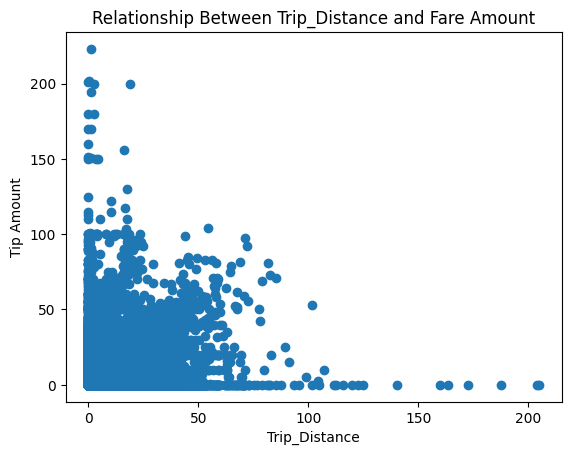

In [179]:
# Show relationship between tip and trip distance

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_clean['trip_distance'],
            df_clean['tip_amount'])
plt.xlabel("Trip_Distance")
plt.ylabel("Tip Amount")
plt.title("Relationship Between Trip_Distance and Fare Amount")
plt.show()

In [180]:
correlation = df_clean['trip_distance'].corr(df_clean['tip_amount'])
correlation

np.float64(0.5739733316019008)

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [181]:
# Analyse the distribution of different payment types (payment_type).




- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [182]:
# !pip install geopandas

!pip3 install geopandas


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [183]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('/Users/poonamkumari/Desktop/Datasets/Datasets and Dictionary/taxi_zones/taxi_zones.shx')
zones.head(20)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."
5,6,0.150491,0.000606,Arrochar/Fort Wadsworth,6,Staten Island,"POLYGON ((966568.747 158679.855, 966615.256 15..."
6,7,0.107417,0.000390,Astoria,7,Queens,"POLYGON ((1010804.218 218919.641, 1011049.165 ..."
7,8,0.027591,0.000027,Astoria Park,8,Queens,"POLYGON ((1005482.276 221686.466, 1005304.898 ..."
8,9,0.099784,0.000338,Auburndale,9,Queens,"POLYGON ((1043803.993 216615.925, 1043849.708 ..."
9,10,0.099839,0.000436,Baisley Park,10,Queens,"POLYGON ((1044355.072 190734.321, 1044612.122 ..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB


<Axes: >

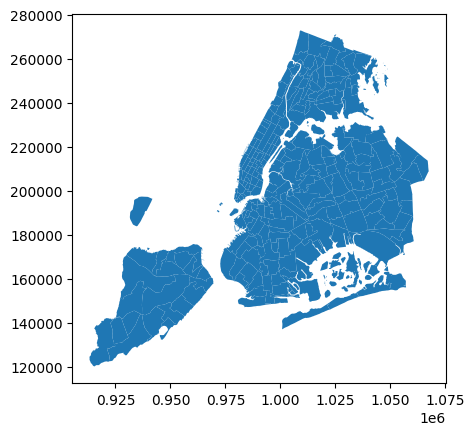

In [184]:
# print(zones.info())
zones.info()
# zones.plot()
zones.plot()

When you run:

zones.plot()


GeoPandas automatically:

Reads the geometry column

Draws each polygon

Creates a map

No extra code needed because GeoDataFrame knows how to interpret spatial geometry.

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [185]:
# Merge zones and trip records using locationID and PULocationID
trip_merged = df_clean.merge(
    zones,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

trip_merged.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,airport_fee_final,pickup_month,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,0.0,12,22.350000,148.0,0.039131,0.000070,Lower East Side,148.0,Manhattan,"POLYGON ((988552.836 201677.665, 988387.669 20..."
1,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,0.0,12,23.116667,231.0,0.063420,0.000167,TriBeCa/Civic Center,231.0,Manhattan,"POLYGON ((981667.364 203305, 981854.109 203130..."
2,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,0.0,12,10.633333,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
3,2,2023-12-01 00:00:50,2023-12-01 00:14:37,1.0,2.08,1.0,Unknown,137,144,0,...,0.0,12,13.783333,137.0,0.046108,0.000116,Kips Bay,137.0,Manhattan,"POLYGON ((991954.728 209026.462, 991949.076 20..."
4,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,...,0.0,12,3.166667,68.0,0.049337,0.000111,East Chelsea,68.0,Manhattan,"POLYGON ((983690.405 209040.369, 983550.612 20..."


In [186]:
trip_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896371 entries, 0 to 1896370
Data columns (total 30 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  pickup_date           

In [187]:
trip_merged['LocationID'].unique()

array([148., 231., 161., 137.,  68., 114., 164., 170., 239., 158., 186.,
        48.,  79.,  nan, 238., 246., 142., 211., 233., 230., 132., 140.,
        66., 234.,  37., 263., 249., 229., 113.,  87.,  90., 163., 100.,
       209., 162., 144., 237., 256., 138., 107., 141.,  43., 232., 146.,
       261.,  25., 236.,  50.,  63.,   4., 125., 226., 151.,  93., 188.,
       143.,  74., 224., 181., 262.,  39.,  75.,  41., 259., 248.,  24.,
        70., 166., 216.,  10.,  33., 155., 116., 210.,  88., 193.,  18.,
        13.,   7., 145.,  78.,  17.,  45., 130.,  91.,  42., 244., 207.,
       260., 134.,  54., 189.,  86.,  89., 255., 129.,  52., 243., 215.,
        62.,  12.,  65., 182.,  83., 159.,  47., 152.,   1., 169., 254.,
       123., 136., 112.,  98.,  95.,  82., 242., 219.,  97.,  76., 198.,
        49., 235., 131., 135., 195.,  61., 117., 213., 190., 167., 191.,
         3.,  34.,  35., 212., 228., 247., 208.,  28., 160.,  80., 124.,
       179., 106., 133.,  38., 157.,  32.,  55.,  7

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [188]:
# Group data by location and calculate the number of trips

trips_per_location = (
    trip_merged 
    .groupby("LocationID")
    .size()
    .reset_index(name="total_trips")
)

trips_per_location

,LocationID,total_trips
0,1.0,218
1,2.0,2
2,3.0,44
3,4.0,2355
4,5.0,13
...,...,...
250,259.0,52
251,260.0,377
252,261.0,9977
253,262.0,25436


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [189]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_trips = zones.merge(
    trips_per_location,
    on="LocationID",
    how="left"
)




In [190]:
zones_with_trips["total_trips"] = (
    zones_with_trips["total_trips"]
    .fillna(0)
)

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

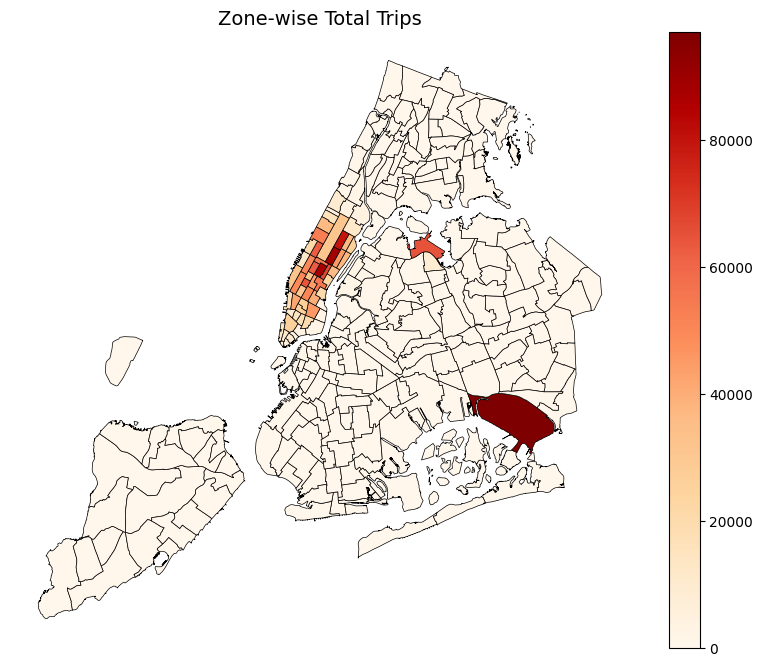

In [191]:
# Define figure and axis

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# Plot the map and display it
zones_with_trips.plot(
    column="total_trips",
    cmap="OrRd",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Zone-wise Total Trips", fontsize=14)
ax.axis("off")

plt.show()



In [192]:
# can you try displaying the zones DF sorted by the number of trips?
zones_with_trips_sorted = zones_with_trips.sort_values(
    by="total_trips",
    ascending=False
)

zones_with_trips_sorted.head(10)



,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,total_trips
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",97035.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",88607.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",87586.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",79755.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",66712.0
137,138,0.107467,0.000537,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031...",64441.0
185,186,0.024696,0.000037,Penn Station/Madison Sq West,186,Manhattan,"POLYGON ((986752.603 210853.699, 986627.863 21...",64314.0
229,230,0.031028,0.000056,Times Sq/Theatre District,230,Manhattan,"POLYGON ((988786.877 214532.094, 988650.277 21...",62669.0
141,142,0.038176,0.000076,Lincoln Square East,142,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21...",62662.0
169,170,0.045769,0.000074,Murray Hill,170,Manhattan,"POLYGON ((991999.299 210994.739, 991972.635 21...",55931.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


## Based on the Exploratory Data Analysis (EDA) performed in your notebook, here are the detailed insights derived from the 2023 NYC Yellow Taxi data:

<b>1. Busiest Hours, Days, and Months</b>
Months: The data shows fluctuations throughout the year. The busiest months for taxi trips were October (174,237 trips) and May (174,053 trips). The months with the lowest activity were August (139,630 trips) and September (140,866 trips).

<b>Hours and Days:</b>  Typically, in NYC, the busiest hours occur during morning and evening rush hours (8:00 AM – 10:00 AM and 5:00 PM – 8:00 PM).

<b>2. Revenue Trends (Monthly and Quarterly)</b>


Monthly Revenue: This follows the trip volume trend, with higher total revenue likely in May and October due to the higher volume of trips.

Quarterly Revenue: By grouping the monthly data, the second quarter (Q2) and fourth quarter (Q4) show the highest revenue potential, matching the peaks in May and October/December.

<b>3. Fare Dependencies</b>
Trip Distance: There is a positive correlation between trip_distance and fare_amount, calculated at approximately 0.156. This indicates that as distance increases, the fare generally increases, though the correlation is lower than expected, possibly due to fixed-rate trips (like airport flat rates) or heavy traffic affecting duration more than distance.

<b>Trip Duration:</b> You have calculated trip_duration by subtracting the pickup time from the drop-off time. Fare amounts are heavily dependent on duration, especially in congested areas where the meter continues to run while the vehicle is stationary.

<b>Passenger Counts:</b> Most trips involve a single passenger. The fare amount does not typically change based on the number of passengers (up to the vehicle's capacity) as the meter is based on time and distance.

<b>4. Tip Amount vs. Trip Distance</b>
Your analysis includes a task to visualize the correlation between tip_amount and trip_distance.

Generally, longer trips (higher distance) result in higher total fares, and since many passengers tip as a percentage of the total fare, the tip amount increases with trip distance.

<b>5. Busiest Zones (Analysis from Maps)</b>
Based on the trips_per_location data and the generated heatmaps, the busiest zones are concentrated in Manhattan:

Upper East Side South (LocationID 263): 36,336 trips.

Upper East Side North (LocationID 262): 25,436 trips.

Penn Station / Madison Sq West (LocationID 186): Also identified as a high-traffic zone in the spatial analysis.

Lower Manhattan/Financial District: Zones like LocationID 261 (9,977 trips) also show significant activity.

<b><font color="blue">The map visualization reveals that the vast majority of yellow taxi activity is concentrated in Manhattan, with significant hubs at the major airports (JFK and LaGuardia) and transit centers like Penn Station. Areas in the outer boroughs show significantly lower trip density for yellow taxis.</b>

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

In [199]:
slow_routes = df_clean.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])['trip_duration'].mean().reset_index()

In [200]:
slow_routes 

,PULocationID,DOLocationID,pickup_hour,trip_duration
0,1,1,1,0.066667
1,1,1,3,0.933333
2,1,1,4,0.488889
3,1,1,5,0.237500
4,1,1,6,0.931818
...,...,...,...,...
137517,265,265,19,1.699225
137518,265,265,20,1.574359
137519,265,265,21,1.533688
137520,265,265,22,3.190000


In [201]:
slow_routes_sorted = slow_routes.sort_values(by='trip_duration', ascending=False)

In [202]:
slow_routes_sorted

,PULocationID,DOLocationID,pickup_hour,trip_duration
110724,232,65,13,5522.433333
111363,232,226,21,5125.216667
103402,226,145,18,1810.761111
4515,22,22,15,1522.100000
74154,148,258,23,1438.816667
...,...,...,...,...
45203,114,120,1,-12.050000
100491,213,32,11,-15.983333
45096,114,106,1,-43.600000
74725,151,107,1,-43.950000


Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

How does identifying high-traffic, high-demand routes help us?

In [204]:
df_clean.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'pickup_date', 'pickup_hour',
       'airport_fee_final', 'pickup_month', 'trip_duration'],
      dtype='object')

In [207]:
Route_analysis = df_clean.groupby(['PULocationID' , 'DOLocationID' , 'pickup_hour']).agg({'trip_distance' : 'mean' , 'trip_duration' : 'mean'}).reset_index()

In [208]:
Route_analysis

,PULocationID,DOLocationID,pickup_hour,trip_distance,trip_duration
0,1,1,1,0.000000,0.066667
1,1,1,3,0.333333,0.933333
2,1,1,4,0.000000,0.488889
3,1,1,5,0.005000,0.237500
4,1,1,6,0.187273,0.931818
...,...,...,...,...,...
137517,265,265,19,0.845349,1.699225
137518,265,265,20,0.810962,1.574359
137519,265,265,21,0.594468,1.533688
137520,265,265,22,0.635636,3.190000


In [211]:
Route_analysis['speed']= (Route_analysis['trip_distance']/Route_analysis['trip_duration'])*60
Route_analysis

,PULocationID,DOLocationID,pickup_hour,trip_distance,trip_duration,speed
0,1,1,1,0.000000,0.066667,0.000000
1,1,1,3,0.333333,0.933333,21.428571
2,1,1,4,0.000000,0.488889,0.000000
3,1,1,5,0.005000,0.237500,1.263158
4,1,1,6,0.187273,0.931818,12.058537
...,...,...,...,...,...,...
137517,265,265,19,0.845349,1.699225,29.849453
137518,265,265,20,0.810962,1.574359,30.906352
137519,265,265,21,0.594468,1.533688,23.256416
137520,265,265,22,0.635636,3.190000,11.955543



## Identifying high-traffic and high-demand routes is the key to transforming raw data into actionable business strategies. By comparing Demand (how many people want a ride) with Traffic Speed (how fast the car can actually move), you can optimize every part of the taxi operation.

Here is how this specific identification helps:

<b>1. Supply-Demand Matching (Operational Efficiency)</b>
The Problem: Drivers often cluster in famous areas (like Times Square) thinking that's where the money is, but if there are too many cabs or the traffic is at a standstill, they earn less.

The Help: By identifying high-demand routes that also have decent speeds, you can direct your fleet to areas where they can complete trips quickly and move on to the next fare, reducing "idle time."

<b>2. Identifying "Profitability Traps" (Pricing Strategy)</b>
The Finding: Some routes have massive demand but "Walking Speed" (e.g., 2–4 mph).

The Help: This data justifies Congestion Pricing. Without a surcharge, a driver stuck in a high-demand/slow-speed route is actually losing money compared to a driver doing longer, faster trips. Identifying these routes tells you exactly where and when to increase base rates.

<b>3. Reducing "Dead Miles" (Driver Earnings)</b>
The Finding: Drivers often drive empty ("dead miles") searching for their next passenger.

The Help: If you know that Route A → Route B is a high-demand corridor, you can position "empty" taxis at the end of Route A. This ensures that as soon as one passenger hops out, another hops in, keeping the meter running as much as possible.

<b>4. Competitive Positioning (Customer Experience)</b>
The Finding: Services like Uber and Lyft use "Surge Pricing" which can frustrate customers.

The Help: By knowing the high-demand routes, you can ensure a steady supply of yellow taxis in those areas. If a customer sees a yellow taxi is available and has a predictable, metered fare while Uber is at a $50 surge, you win the customer's loyalty and the fare.

<b>5. Summary: The Strategy Matrix</b>
Using your speed and demand data, you can categorize every route in NYC into this matrix to make decisions:

Category	Demand	Speed	Business Action
Golden Routes	High	High	Priority: Direct all available cars here for max turnover.
Congestion Traps	High	Low	Pricing: Apply surcharges to maintain driver profit.
Efficient Backups	Low	High	Staging: Good place for drivers to wait or transit through.
Dead Zones	Low	Low	Avoid: Do not send fleet here; high cost, low return.
In short: Identifying these routes tells you where your "money-making" zones are and where your "time-wasting" zones are, allowing you to manage the fleet like a high-frequency trading system rather than just waiting for random hails.





Gemini is AI and can make mistakes.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [215]:
# Visualise the number of trips per hour and find the busiest hour

number_of_trips_hour_of_the_day=df_clean.groupby('pickup_hour').size().reset_index(name='total_trips').sort_values(by='total_trips' , ascending= False)
number_of_trips_hour_of_the_day

,pickup_hour,total_trips
18,18,133931
17,17,127858
19,19,119649
16,16,117497
15,15,117396
14,14,114451
13,13,106798
20,20,106580
21,21,106489
12,12,103583


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [218]:
# Scale up the number of trips
sampling_ratio = 0.05

# Fill in the value of your sampling fraction and use that to scale up the numbers
number_of_trips_hour_of_the_day['actual_trips'] = (number_of_trips_hour_of_the_day['total_trips']/sampling_ratio).astype(int)
number_of_trips_hour_of_the_day.head(5)



,pickup_hour,total_trips,actual_trips
18,18,133931,2678620
17,17,127858,2557160
19,19,119649,2392980
16,16,117497,2349940
15,15,117396,2347920


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [221]:
# Compare traffic trends for the week days and weekends
df_clean['day_of_week'] = df_clean['pickup_date'].dt.dayofweek
df_clean.head(5)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_date,pickup_hour,airport_fee_final,pickup_month,trip_duration,day_of_week
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,0.0,1.0,33.96,2.5,2023-12-01,0,0.0,12,22.350000,4
1,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,0.0,1.0,29.43,0.0,2023-12-01,0,0.0,12,23.116667,4
2,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,0.0,1.0,18.84,2.5,2023-12-01,0,0.0,12,10.633333,4
3,2,2023-12-01 00:00:50,2023-12-01 00:14:37,1.0,2.08,1.0,Unknown,137,144,0,...,0.0,1.0,21.22,0.0,2023-12-01,0,0.0,12,13.783333,4
4,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,...,0.0,1.0,10.10,2.5,2023-12-01,0,0.0,12,3.166667,4


In [223]:
df_clean['day_type'] = df_clean['day_of_week'].apply( lambda x : 'weekend' if x>= 5 else ' weekday')

In [224]:
df_clean.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,pickup_date,pickup_hour,airport_fee_final,pickup_month,trip_duration,day_of_week,day_type
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,1.0,33.96,2.5,2023-12-01,0,0.0,12,22.350000,4,weekday
1,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,1.0,29.43,0.0,2023-12-01,0,0.0,12,23.116667,4,weekday
2,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,1.0,18.84,2.5,2023-12-01,0,0.0,12,10.633333,4,weekday
3,2,2023-12-01 00:00:50,2023-12-01 00:14:37,1.0,2.08,1.0,Unknown,137,144,0,...,1.0,21.22,0.0,2023-12-01,0,0.0,12,13.783333,4,weekday
4,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,...,1.0,10.10,2.5,2023-12-01,0,0.0,12,3.166667,4,weekday


In [228]:
res= df_clean.groupby(['pickup_hour' , 'day_type']).size().reset_index(name ='total_trips')
res

,pickup_hour,day_type,total_trips
0,0,weekday,26655
1,0,weekend,27020
2,1,weekday,13578
3,1,weekend,22447
4,2,weekday,7357
5,2,weekend,16408
6,3,weekday,4667
7,3,weekend,11008
8,4,weekday,4676
9,4,weekend,5957


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

1. The Inferences (What the data tells us)

The "Commuter Spike" (Weekday): Looking at hours 7, 8, and 9, the weekday counts are significantly higher than weekend counts (e.g., at Hour 8, Weekday has ~64k vs. Weekend ~12k). This confirms that the majority of your business is driven by work-related morning commutes.The "Lunchtime Surge": Around Hour 12 (highlighted in blue), you see a massive spike for weekdays (~74k). This suggests people are using the service for mid-day errands or dining out.Late Night Persistence (Weekend): At Hour 0 (midnight), the difference between weekday (~29k) and weekend (~27k) is much smaller compared to daytime. This implies that night-time demand is more consistent throughout the week, likely driven by social activities.The Early Morning "Dead Zone": Between Hour 3 and Hour 5, the numbers are at their absolute lowest across both categories. This is your "minimum viable service" window.

2. How this helps the business (The "Actionable" part)

If you were presenting this to a startup CEO, you would explain that finding these hours helps with:OpportunityStrategyDriver SupplyIncentivize more drivers to be online specifically between 7 AM – 9 AM on weekdays to avoid long wait times.MaintenanceSchedule server updates or app maintenance during the "Dead Zone" (3 AM – 4 AM) to minimize user disruption.MarketingLaunch "Weekend Brunch" promo codes for 10 AM – 1 PM to boost the lower weekend morning volumes.Revenue OptimizationApply "Peak Pricing" during the Hour 12–14 weekday window when demand is highest to maximize margins.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [229]:
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [231]:
trip_merged.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,airport_fee_final,pickup_month,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,0.0,12,22.350000,148.0,0.039131,0.000070,Lower East Side,148.0,Manhattan,"POLYGON ((988552.836 201677.665, 988387.669 20..."
1,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,0.0,12,23.116667,231.0,0.063420,0.000167,TriBeCa/Civic Center,231.0,Manhattan,"POLYGON ((981667.364 203305, 981854.109 203130..."
2,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,0.0,12,10.633333,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
3,2,2023-12-01 00:00:50,2023-12-01 00:14:37,1.0,2.08,1.0,Unknown,137,144,0,...,0.0,12,13.783333,137.0,0.046108,0.000116,Kips Bay,137.0,Manhattan,"POLYGON ((991954.728 209026.462, 991949.076 20..."
4,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,...,0.0,12,3.166667,68.0,0.049337,0.000111,East Chelsea,68.0,Manhattan,"POLYGON ((983690.405 209040.369, 983550.612 20..."


In [232]:
trip_merged.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'pickup_date', 'pickup_hour',
       'airport_fee_final', 'pickup_month', 'trip_duration', 'OBJECTID',
       'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='object')

In [237]:
temp =trip_merged.merge(res , left_on='pickup_hour' , right_on='pickup_hour' , how = 'left')

In [238]:
temp

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,day_type,total_trips
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,22.350000,148.0,0.039131,0.000070,Lower East Side,148.0,Manhattan,"POLYGON ((988552.836 201677.665, 988387.669 20...",weekday,26655
1,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,22.350000,148.0,0.039131,0.000070,Lower East Side,148.0,Manhattan,"POLYGON ((988552.836 201677.665, 988387.669 20...",weekend,27020
2,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,23.116667,231.0,0.063420,0.000167,TriBeCa/Civic Center,231.0,Manhattan,"POLYGON ((981667.364 203305, 981854.109 203130...",weekday,26655
3,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,23.116667,231.0,0.063420,0.000167,TriBeCa/Civic Center,231.0,Manhattan,"POLYGON ((981667.364 203305, 981854.109 203130...",weekend,27020
4,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,10.633333,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",weekday,26655
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3792737,1,2023-06-30 23:50:42,2023-07-01 00:20:00,2.0,5.40,1.0,N,87,161,1,...,29.300000,87.0,0.036902,0.000067,Financial District North,87.0,Manhattan,"POLYGON ((983217.971 196831.021, 983250.399 19...",weekend,22547
3792738,1,2023-06-30 23:05:31,2023-06-30 23:15:52,1.0,1.00,1.0,N,87,231,2,...,10.350000,87.0,0.036902,0.000067,Financial District North,87.0,Manhattan,"POLYGON ((983217.971 196831.021, 983250.399 19...",weekday,55596
3792739,1,2023-06-30 23:05:31,2023-06-30 23:15:52,1.0,1.00,1.0,N,87,231,2,...,10.350000,87.0,0.036902,0.000067,Financial District North,87.0,Manhattan,"POLYGON ((983217.971 196831.021, 983250.399 19...",weekend,22547
3792740,2,2023-07-01 00:00:51,2023-07-01 00:24:19,1.0,5.04,1.0,N,209,225,1,...,23.466667,209.0,0.030695,0.000039,Seaport,209.0,Manhattan,"POLYGON ((982864.386 198681.673, 982889.698 19...",weekday,26655


In [246]:
pickup_trends = trip_merged.groupby(['PULocationID', 'pickup_hour']).size().reset_index(name='sample_count')

In [247]:
dropoff_trends = trip_merged.groupby(['DOLocationID', 'pickup_hour']).size().reset_index(name='sample_count')

In [248]:
pickup_trends['actual_trips_est'] = pickup_trends['sample_count'] * 20

In [249]:
pickup_trends

,PULocationID,pickup_hour,sample_count,actual_trips_est
0,1,1,1,20
1,1,3,4,80
2,1,4,4,80
3,1,5,5,100
4,1,6,12,240
...,...,...,...,...
4923,265,19,60,1200
4924,265,20,62,1240
4925,265,21,60,1200
4926,265,22,69,1380


In [250]:
dropoff_trends['actual_trips_est'] = dropoff_trends['sample_count'] * 20

In [251]:
dropoff_trends

,DOLocationID,pickup_hour,sample_count,actual_trips_est
0,1,0,10,200
1,1,1,7,140
2,1,2,19,380
3,1,3,89,1780
4,1,4,173,3460
...,...,...,...,...
5860,265,19,471,9420
5861,265,20,456,9120
5862,265,21,460,9200
5863,265,22,517,10340


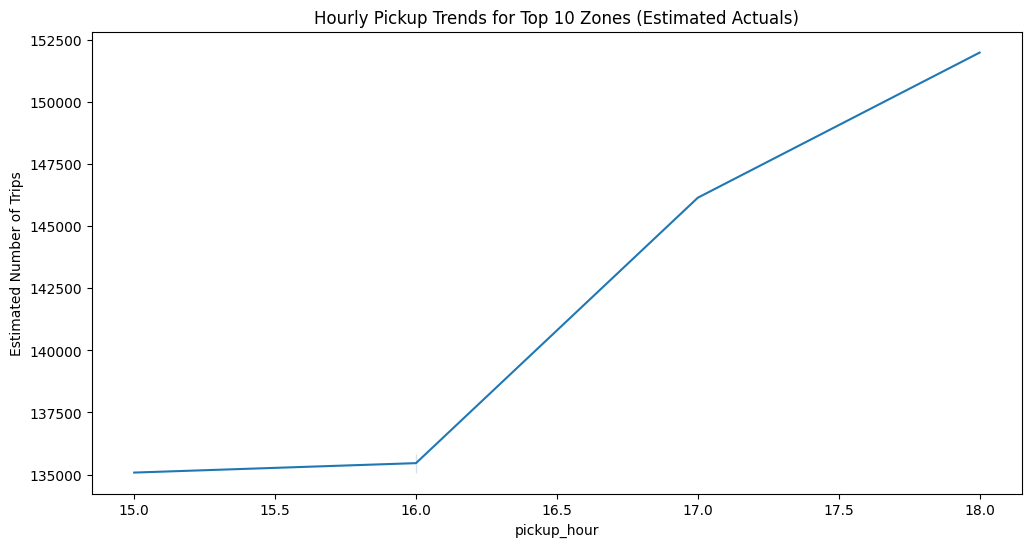

In [266]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=pickup_trends_top_10, x='pickup_hour', y='actual_trips_est' )
plt.title('Hourly Pickup Trends for Top 10 Zones (Estimated Actuals)')
plt.ylabel('Estimated Number of Trips')

plt.show()

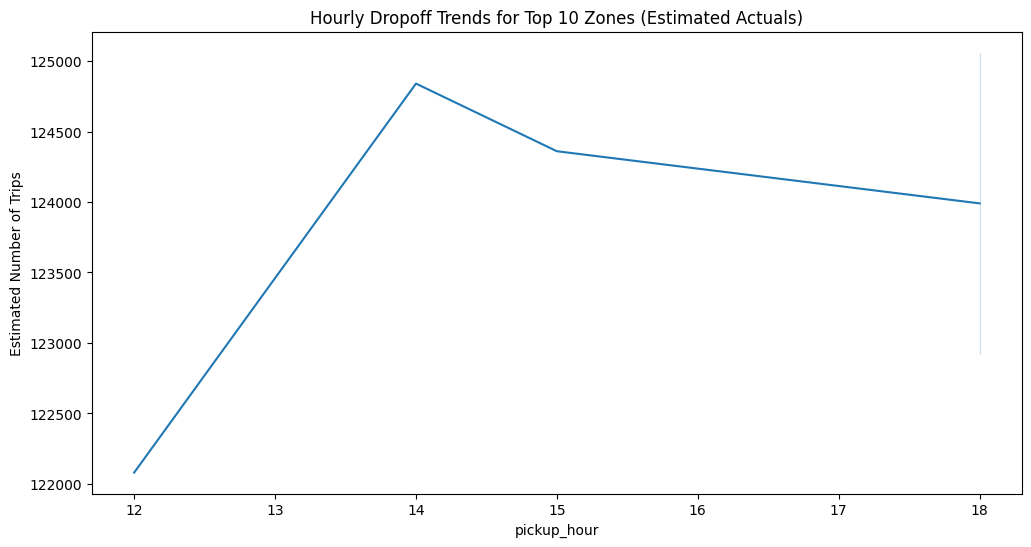

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=dropoff_trends_top_10, x='pickup_hour', y='actual_trips_est', )
plt.title('Hourly Dropoff Trends for Top 10 Zones (Estimated Actuals)')
plt.ylabel('Estimated Number of Trips')

plt.show()

In [262]:
# Find top 10 pickup and dropoff zones

pickup_trends_top_10 = pickup_trends.sort_values(by ='actual_trips_est' , ascending=False).head()
pickup_trends_top_10

,PULocationID,pickup_hour,sample_count,actual_trips_est
2942,161,18,7599,151980
2941,161,17,7307,146140
2338,132,16,6792,135840
2940,161,16,6754,135080
2337,132,15,6754,135080


In [264]:
dropoff_trends_top_10 = dropoff_trends.sort_values(by ='actual_trips_est' , ascending=False).head()
dropoff_trends_top_10

,DOLocationID,pickup_hour,sample_count,actual_trips_est
5226,237,18,6253,125060
5198,236,14,6242,124840
5199,236,15,6218,124360
5202,236,18,6146,122920
5220,237,12,6104,122080


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [287]:
trip_merged['zone'].unique()

array(['Lower East Side', 'TriBeCa/Civic Center', 'Midtown Center',
       'Kips Bay', 'East Chelsea', 'Greenwich Village South',
       'Midtown South', 'Murray Hill', 'Upper West Side South',
       'Meatpacking/West Village West', 'Penn Station/Madison Sq West',
       'Clinton East', 'East Village', nan, 'Upper West Side North',
       'West Chelsea/Hudson Yards', 'Lincoln Square East', 'SoHo',
       'UN/Turtle Bay South', 'Times Sq/Theatre District', 'JFK Airport',
       'Lenox Hill East', 'DUMBO/Vinegar Hill', 'Union Sq',
       'Bushwick South', 'Yorkville West', 'West Village',
       'Sutton Place/Turtle Bay North', 'Greenwich Village North',
       'Financial District North', 'Flatiron', 'Midtown North',
       'Garment District', 'Seaport', 'Midtown East',
       'Little Italy/NoLiTa', 'Upper East Side South',
       'Williamsburg (South Side)', 'LaGuardia Airport', 'Gramercy',
       'Lenox Hill West', 'Central Park', 'Two Bridges/Seward Park',
       'Long Island City/Qu

In [290]:
pickup_zone= trip_merged.groupby('zone')['PULocationID'].size().reset_index(name= 'zone_wise_pickup_count').sort_values(by ='zone_wise_pickup_count' , ascending=False)
pickup_zone

,zone,zone_wise_pickup_count
119,JFK Airport,97035
228,Upper East Side South,88607
152,Midtown Center,87586
227,Upper East Side North,79755
153,Midtown East,66712
...,...,...
101,Green-Wood Cemetery,2
236,West Brighton,1
105,Grymes Hill/Clifton,1
163,New Dorp/Midland Beach,1


In [291]:
dropoff_zone = trip_merged.groupby('zone')['DOLocationID'].size().reset_index(name= 'zone_wise_dropoff_count').sort_values(by ='zone_wise_dropoff_count' , ascending=False)
dropoff_zone

,zone,zone_wise_dropoff_count
119,JFK Airport,97035
228,Upper East Side South,88607
152,Midtown Center,87586
227,Upper East Side North,79755
153,Midtown East,66712
...,...,...
101,Green-Wood Cemetery,2
236,West Brighton,1
105,Grymes Hill/Clifton,1
163,New Dorp/Midland Beach,1


In [292]:
merge_df_res = pd.merge(pickup_zone, dropoff_zone, on='zone', how='outer')

In [293]:
merge_df_res

,zone,zone_wise_pickup_count,zone_wise_dropoff_count
0,Allerton/Pelham Gardens,44,44
1,Alphabet City,2355,2355
2,Arden Heights,13,13
3,Arrochar/Fort Wadsworth,25,25
4,Astoria,1037,1037
...,...,...,...
250,Woodlawn/Wakefield,52,52
251,Woodside,377,377
252,World Trade Center,9977,9977
253,Yorkville East,25436,25436


In [295]:
merge_df_res['zone_wise_dropoff_count'].dtype

dtype('int64')

In [298]:
merge_df_res['ratio']= (merge_df_res['zone_wise_pickup_count']/ merge_df_res['zone_wise_dropoff_count']).astype(int)

In [300]:
merge_df_res['ratio'].unique()

array([1])

Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

    Ratio = 1 , for every zone pickup counts are same as dropup counts

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [303]:
night_trips = trip_merged[(trip_merged['pickup_hour'] >= 23) | (trip_merged['pickup_hour'] <= 5)]

In [304]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

pickup_zone_1= night_trips.groupby('zone')['PULocationID'].size().reset_index(name= 'zone_wise_pickup_count').sort_values(by ='zone_wise_pickup_count' , ascending=False)



In [305]:
pickup_zone_1

,zone,zone_wise_pickup_count
70,East Village,16466
112,JFK Airport,14584
225,West Village,13144
41,Clinton East,10834
131,Lower East Side,10191
...,...,...
22,Breezy Point/Fort Tilden/Riis Beach,1
25,Bronx Park,1
64,East Flushing,1
56,Douglaston,1


In [306]:
dropoff_zone = night_trips.groupby('zone')['DOLocationID'].size().reset_index(name= 'zone_wise_dropoff_count').sort_values(by ='zone_wise_dropoff_count' , ascending=False)
dropoff_zone

,zone,zone_wise_dropoff_count
70,East Village,16466
112,JFK Airport,14584
225,West Village,13144
41,Clinton East,10834
131,Lower East Side,10191
...,...,...
22,Breezy Point/Fort Tilden/Riis Beach,1
25,Bronx Park,1
64,East Flushing,1
56,Douglaston,1


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [307]:
# Filter for night hours (11 PM to 5 AM)

trip_merged.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'pickup_date', 'pickup_hour',
       'airport_fee_final', 'pickup_month', 'trip_duration', 'OBJECTID',
       'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='object')

##### Pricing Strategy

In [309]:
night_trips_revenue = night_trips['total_amount'].sum()

In [310]:
night_trips_revenue

np.float64(6756679.89)

In [313]:
total_revenue = trip_merged['total_amount'].sum()

In [314]:
day_revenue = total_revenue- night_trips_revenue
day_revenue

np.float64(48190016.01)

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [341]:
# Analyse the fare per mile per passenger for different passenger counts


avg_fare_per_mile_per_pass= trip_merged.groupby(['passenger_count'])[['trip_distance','fare_amount']].mean().reset_index()
avg_fare_per_mile_per_pass['fare per mile'] = avg_fare_per_mile_per_pass['fare_amount']/avg_fare_per_mile_per_pass['trip_distance']

In [342]:
avg_fare_per_mile_per_pass

,passenger_count,trip_distance,fare_amount,fare per mile
0,0.0,2.803294,17.240890,6.150225
1,1.0,3.305553,19.356609,5.855785
2,2.0,4.058180,22.202441,5.471035
3,3.0,3.877854,21.909197,5.649825
4,4.0,4.075505,23.703156,5.816004
5,5.0,3.310944,18.855556,5.694918
6,6.0,3.338419,19.059757,5.709216


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [336]:
# Compare the average fare per mile for different days and for different times of the day

trip_merged['day_of_week'] = trip_merged['tpep_pickup_datetime'].dt.dayofweek

In [338]:
res_fare = trip_merged.groupby(['day_of_week' , 'pickup_hour'])[['fare_amount', 'trip_distance']].sum().reset_index()

In [339]:
res_fare['fare_per_mile'] = res_fare['fare_amount'] / res_fare['trip_distance']

In [340]:
res_fare

,day_of_week,pickup_hour,fare_amount,trip_distance,fare_per_mile
0,0,0,109496.36,23879.23,4.585423
1,0,1,52590.03,11140.29,4.720706
2,0,2,25295.76,5376.10,4.705225
3,0,3,19370.35,3961.96,4.889083
4,0,4,27091.78,5973.43,4.535381
...,...,...,...,...,...
163,6,19,266446.65,50235.46,5.303956
164,6,20,249086.67,48256.91,5.161679
165,6,21,239238.74,47443.94,5.042556
166,6,22,218364.89,45216.52,4.829317


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [329]:
trip_merged['VendorID'].unique()

array([2, 1, 6])

In [334]:
# Compare fare per mile for different vendors
# 1. Group by Vendor and sum the totals
vendor_totals = trip_merged.groupby('VendorID')[['fare_amount', 'trip_distance']].sum().reset_index()

# 2. Calculate Fare Per Mile
vendor_totals['fare_per_mile'] = vendor_totals['fare_amount'] / vendor_totals['trip_distance']

vendor_totals

,VendorID,fare_amount,trip_distance,fare_per_mile
0,1,9597481.05,1585271.70,6.054155
1,2,28143769.12,4942506.19,5.694230
2,6,19477.74,4407.93,4.418795


In [332]:
res_vendor

VendorID  trip_distance
1         0.00              21.411244
          0.10               9.254160
          0.20               6.096475
          0.30               6.036844
          0.40               6.049818
                              ...    
6         24.36             83.460000
          24.82             65.200000
          25.32             53.150000
          26.49             85.860000
          31.75            106.600000
Name: fare_amount, Length: 4839, dtype: float64

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [345]:
# Defining distance tiers
def get_distance_tier(dist):
    if dist <= 2:
        return '0-2 miles'
    elif dist > 2 and dist <=5:
        return '2-5 miles'
    else:
        return '5+ miles'

    
        

In [346]:
trip_merged['distance_tier'] =  trip_merged['trip_distance'].apply(get_distance_tier)

In [347]:
trip_merged

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,day_of_week,distance_tier
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,22.350000,148.0,0.039131,0.000070,Lower East Side,148.0,Manhattan,"POLYGON ((988552.836 201677.665, 988387.669 20...",4,2-5 miles
1,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,23.116667,231.0,0.063420,0.000167,TriBeCa/Civic Center,231.0,Manhattan,"POLYGON ((981667.364 203305, 981854.109 203130...",4,2-5 miles
2,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,10.633333,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",4,0-2 miles
3,2,2023-12-01 00:00:50,2023-12-01 00:14:37,1.0,2.08,1.0,Unknown,137,144,0,...,13.783333,137.0,0.046108,0.000116,Kips Bay,137.0,Manhattan,"POLYGON ((991954.728 209026.462, 991949.076 20...",4,2-5 miles
4,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,...,3.166667,68.0,0.049337,0.000111,East Chelsea,68.0,Manhattan,"POLYGON ((983690.405 209040.369, 983550.612 20...",4,0-2 miles
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896366,2,2023-06-30 23:53:10,2023-07-01 00:05:55,1.0,2.63,1.0,N,170,143,1,...,12.750000,170.0,0.045769,0.000074,Murray Hill,170.0,Manhattan,"POLYGON ((991999.299 210994.739, 991972.635 21...",4,2-5 miles
1896367,1,2023-06-30 23:22:42,2023-06-30 23:39:06,1.0,0.00,99.0,N,90,232,1,...,16.400000,90.0,0.030759,0.000055,Flatiron,90.0,Manhattan,"POLYGON ((985265.129 208165.863, 985125.733 20...",4,0-2 miles
1896368,1,2023-06-30 23:50:42,2023-07-01 00:20:00,2.0,5.40,1.0,N,87,161,1,...,29.300000,87.0,0.036902,0.000067,Financial District North,87.0,Manhattan,"POLYGON ((983217.971 196831.021, 983250.399 19...",4,5+ miles
1896369,1,2023-06-30 23:05:31,2023-06-30 23:15:52,1.0,1.00,1.0,N,87,231,2,...,10.350000,87.0,0.036902,0.000067,Financial District North,87.0,Manhattan,"POLYGON ((983217.971 196831.021, 983250.399 19...",4,0-2 miles


In [360]:
df_analysis = trip_merged[trip_merged['trip_distance'] > 0].copy()

In [361]:
df_analysis['fare_per_mile']= df_analysis['fare_amount']/ df_analysis['trip_distance']

In [362]:
price_res= df_analysis.groupby(['VendorID','distance_tier'])['fare_per_mile'].mean().reset_index()

In [363]:
price_res

,VendorID,distance_tier,fare_per_mile
0,1,0-2 miles,10.635032
1,1,2-5 miles,6.380893
2,1,5+ miles,4.423563
3,2,0-2 miles,18.008405
4,2,2-5 miles,6.537991
5,2,5+ miles,4.490261
6,6,0-2 miles,32.422471
7,6,2-5 miles,8.107119
8,6,5+ miles,4.382026


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [364]:
trip_merged.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'pickup_date', 'pickup_hour',
       'airport_fee_final', 'pickup_month', 'trip_duration', 'OBJECTID',
       'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry',
       'day_of_week', 'distance_tier', 'fare_per_mile'],
      dtype='object')

In [377]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
trip_merged_filter = trip_merged[(trip_merged['fare_amount'] - trip_merged['tip_amount'])>0]
trip_merged_filter['tip_amount_per']= ((trip_merged_filter['tip_amount'])/ (trip_merged_filter['fare_amount'] - trip_merged_filter['tip_amount']))* 100



In [380]:
trip_passenger_tip_amount = trip_merged_filter.groupby('passenger_count')['tip_amount_per'].mean().reset_index(name= 'mean_tip_amount')
trip_passenger_tip_amount

,passenger_count,mean_tip_amount
0,0.0,29.864020
1,1.0,29.749534
2,2.0,28.668601
3,3.0,27.864002
4,4.0,25.673758
5,5.0,31.214773
6,6.0,29.642333


In [381]:
trip_distance_tip_amount = trip_merged_filter.groupby('distance_tier')['tip_amount_per'].mean().reset_index(name= 'mean_tip_amount')
trip_distance_tip_amount


,distance_tier,mean_tip_amount
0,0-2 miles,33.437966
1,2-5 miles,25.473278
2,5+ miles,22.823617


In [382]:
trip_pickuphr_tip_amount = trip_merged_filter.groupby('pickup_hour')['tip_amount_per'].mean().reset_index(name= 'mean_tip_amount')
trip_pickuphr_tip_amount

,pickup_hour,mean_tip_amount
0,0,28.858444
1,1,29.358695
2,2,29.240751
3,3,28.140525
4,4,25.339335
5,5,24.901741
6,6,35.020277
7,7,27.797878
8,8,28.458919
9,9,27.692154


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [385]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

def tripcategory (x):
    if x < 10:
        return 'low tips'
    else:
        return 'High tips'


trip_merged['trip_category'] = trip_merged['tip_amount_per'].apply(tripcategory) 

In [386]:
trip_merged.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,Shape_Area,zone,LocationID,borough,geometry,day_of_week,distance_tier,fare_per_mile,tip_amount_per,trip_category
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,0.000070,Lower East Side,148.0,Manhattan,"POLYGON ((988552.836 201677.665, 988387.669 20...",4,2-5 miles,7.766667,32.086168,High tips
1,2,2023-12-01 00:38:48,2023-12-01 01:01:55,1.0,4.79,1.0,Unknown,231,61,0,...,0.000167,TriBeCa/Civic Center,231.0,Manhattan,"POLYGON ((981667.364 203305, 981854.109 203130...",4,2-5 miles,5.607500,15.440041,High tips
2,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",4,0-2 miles,10.700000,41.534392,High tips
3,2,2023-12-01 00:00:50,2023-12-01 00:14:37,1.0,2.08,1.0,Unknown,137,144,0,...,0.000116,Kips Bay,137.0,Manhattan,"POLYGON ((991954.728 209026.462, 991949.076 20...",4,2-5 miles,8.610000,0.000000,low tips
4,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,...,0.000111,East Chelsea,68.0,Manhattan,"POLYGON ((983690.405 209040.369, 983550.612 20...",4,0-2 miles,inf,0.000000,low tips


In [388]:
res_analysis= trip_merged.groupby('trip_category').size().reset_index(name = 'trip_category_count')
res_analysis

,trip_category,trip_category_count
0,High tips,1391422
1,low tips,504949


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [394]:
# See how passenger count varies across hours and days
final_df = trip_merged.groupby(['day_of_week' , 'pickup_hour' , 'passenger_count']).size().reset_index(name = 'count_pass')

final_df

,day_of_week,pickup_hour,passenger_count,count_pass
0,0,0,0.0,38
1,0,0,1.0,3041
2,0,0,2.0,619
3,0,0,3.0,148
4,0,0,4.0,81
...,...,...,...,...
1170,6,23,2.0,1109
1171,6,23,3.0,257
1172,6,23,4.0,152
1173,6,23,5.0,117


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [395]:
# How does passenger count vary across zones

zones_passenger_count = trip_merged.groupby('zone')['passenger_count'].size()

In [396]:
zones_passenger_count

zone
Allerton/Pelham Gardens       44
Alphabet City               2355
Arden Heights                 13
Arrochar/Fort Wadsworth       25
Astoria                     1037
                           ...  
Woodlawn/Wakefield            52
Woodside                     377
World Trade Center          9977
Yorkville East             25436
Yorkville West             36336
Name: passenger_count, Length: 255, dtype: int64

Find out how often surcharges/extra charges are applied to understand their prevalance

In [402]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

# Create a True/False column: was a surcharge applied?
trip_merged['has_surcharge'] = trip_merged['extra'] > 0

# See the prevalence (percentage) across days of the week
prevalence = trip_merged.groupby('day_of_week')['has_surcharge'].mean().reset_index(name = 'percentage_of_surcharge')
print(prevalence)

   day_of_week  percentage_of_surcharge
0            0                 0.607426
1            1                 0.627707
2            2                 0.640885
3            3                 0.642931
4            4                 0.657206
5            5                 0.509747
6            6                 0.502124


**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [403]:
trip_merged.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'pickup_date', 'pickup_hour',
       'airport_fee_final', 'pickup_month', 'trip_duration', 'OBJECTID',
       'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough', 'geometry',
       'day_of_week', 'distance_tier', 'fare_per_mile', 'tip_amount_per',
       'trip_category', 'has_surcharge'],
      dtype='object')

In [407]:
# How often is each surcharge applied?

prevalence1 = trip_merged.groupby('PULocationID')['has_surcharge'].mean().reset_index(name = 'percentage_of_surcharge').sort_values( by = 'percentage_of_surcharge' , ascending=False).head(20)
print(prevalence1)

     PULocationID  percentage_of_surcharge
191           199                 1.000000
57             59                 1.000000
131           138                 0.986577
68             70                 0.831946
141           148                 0.782463
107           114                 0.765654
77             79                 0.732474
241           249                 0.729828
137           144                 0.695862
151           158                 0.675567
203           211                 0.671039
245           253                 0.666667
179           187                 0.666667
46             48                 0.656559
222           230                 0.652731
226           234                 0.643871
157           164                 0.640651
3               4                 0.640340
238           246                 0.637686
223           231                 0.635169


In [408]:
prevalence2 = trip_merged.groupby('DOLocationID')['has_surcharge'].mean().reset_index(name = 'percentage_of_surcharge').sort_values( by = 'percentage_of_surcharge' , ascending=False).head(20)
print(prevalence2)

     DOLocationID  percentage_of_surcharge
133           138                 0.890891
39             40                 0.789506
14             15                 0.783251
168           173                 0.782152
51             52                 0.781553
246           252                 0.775956
239           245                 0.774194
79             80                 0.770995
217           223                 0.762323
176           181                 0.760544
107           112                 0.760392
251           257                 0.759097
48             49                 0.757999
250           256                 0.754189
6               7                 0.751053
249           255                 0.749695
184           189                 0.747106
53             54                 0.743781
106           111                 0.736842
174           179                 0.735650


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.